In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import timm
from torchvision import transforms

In [3]:
# --- Constants
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
TEST_DIR = "D:/college/grad project/integrated/testing" 

In [5]:
# Input sizes per model
keras_size_eff = (300, 300)  # EfficientNetB3
keras_size_inc = (229, 229)  # InceptionResNetV2
torch_size_vit = 224         # ViT (for torchvision transform)

In [7]:
# --- Load models
efficientnet_model = load_model("saved_model/efficientnet_b3_finetuned_v2.keras")
inceptionresnet_model = load_model("saved_model/inceptionresnetv2_mri_final.keras")

vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)
vit_model.load_state_dict(torch.load("saved_model/Vitbase_model.pth", map_location="cpu"))
vit_model.eval()

D:\anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 494 variables whereas the saved optimizer has 986 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [13]:
# --- Preprocessing
keras_size = (224, 224)
torch_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def ensemble_predict(img_path):
    img = Image.open(img_path).convert("RGB")

    # EfficientNet input: (300x300)
    eff_img = img.resize((300, 300))
    eff_array = img_to_array(eff_img) / 255.0
    eff_array = np.expand_dims(eff_array, axis=0)

    # InceptionResNetV2 input: (299x299)
    inc_img = img.resize((299, 299))
    inc_array = img_to_array(inc_img) / 255.0
    inc_array = np.expand_dims(inc_array, axis=0)

    # ViT input: (224x224)
    vit_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3)
    ])
    vit_tensor = vit_transform(img).unsqueeze(0)

    # Get predictions
    eff_pred = efficientnet_model.predict(eff_array, verbose=0)[0]
    inc_pred = inceptionresnet_model.predict(inc_array, verbose=0)[0]
    with torch.no_grad():
        vit_logits = vit_model(vit_tensor)
        vit_pred = F.softmax(vit_logits, dim=1).cpu().numpy()[0]

    # Weighted ensemble
    final_pred = 0.2 * eff_pred + 0.4 * inc_pred + 0.4 * vit_pred
    return np.argmax(final_pred)

In [15]:
# --- Evaluation
y_true, y_pred = [], []

for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            pred = ensemble_predict(img_path)
            y_pred.append(pred)
            y_true.append(CLASS_IDX[class_name])

In [17]:
# --- Results
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.99      0.91      0.95       400
meningioma_tumor       0.94      1.00      0.97       421
        no_tumor       0.96      1.00      0.98       510
 pituitary_tumor       1.00      0.97      0.99       374

        accuracy                           0.97      1705
       macro avg       0.97      0.97      0.97      1705
    weighted avg       0.97      0.97      0.97      1705



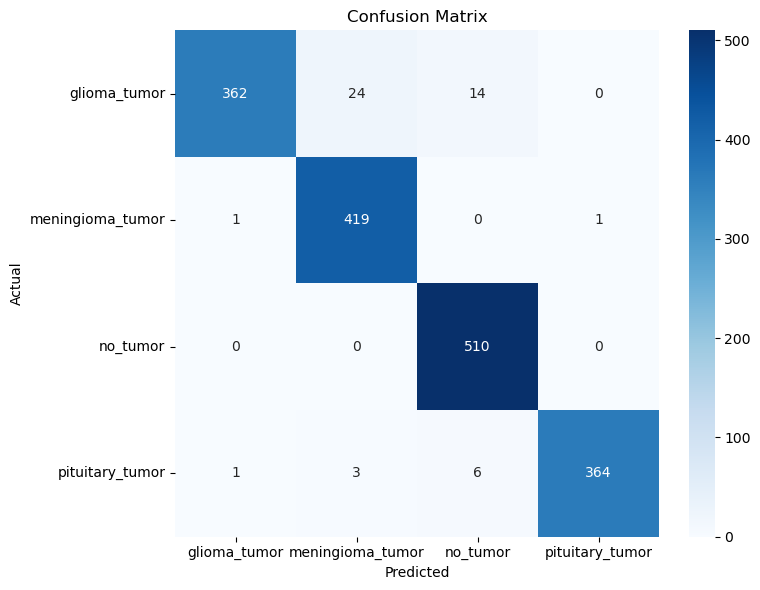

In [19]:
# --- Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()